## Airport AI End-to-End Research Notebook

This notebook implements the complete Airport AI research workflow:

1. Environment Setup
2. Dataset Validation
3. Dataset Statistics & Visualization
4. YOLO26n Training
5. Model Evaluation
6. Video Detection
7. Confidence Analysis
8. Object Tracking
9. Spatial-Temporal Safety Analytics
10. Performance Evaluation
11. Export Results

This notebook serves as the single reproducible workflow for the Airport AI project.

## 1. Environment Setup

In [1]:
# ===================
# Import Libraries
# ===================
import os
import sys
import json
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import yaml
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch
from ultralytics import YOLO

warnings.filterwarnings("ignore")

In [5]:
# ========================
# Configure Project Paths
# ========================
PROJECT_ROOT = Path.cwd().resolve()

DATASET_ROOT = PROJECT_ROOT / "datasets" / "airport"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

DATA_YAML = PROJECT_ROOT / "data.yaml"

In [3]:
# =======================
# Create Output Folders
# =======================
OUTPUT_DIRS = [
    OUTPUT_ROOT,
    OUTPUT_ROOT / "dataset_statistics",
    OUTPUT_ROOT / "dataset_visualizations",
    OUTPUT_ROOT / "validation_reports",
    # OUTPUT_ROOT / "training"
]

for directory in OUTPUT_DIRS:
    directory.mkdir(parents=True, exist_ok=True)

print("Output folders created.")

Output folders created.


In [6]:
# ==============================
# Load Dataset Configuration
# ==============================
with open(DATA_YAML, "r") as f:
    dataset_config = yaml.safe_load(f)

CLASS_NAMES = dataset_config["names"]
NUM_CLASSES = len(CLASS_NAMES)

print(f"Dataset contains {NUM_CLASSES} classes.\n")

for idx, name in enumerate(CLASS_NAMES):
    print(f"{idx}: {name}")

Dataset contains 6 classes.

0: aircraft
1: airport tug
2: cone
3: ground support equipment
4: safety vest
5: worker


In [7]:
# ========================
# Configure Random Seeds
# ========================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [7]:
# ====================
# System Information
# ====================
print("="*60)

print("Airport AI Research Environment")

print("="*60)

print("Python :", sys.version.split()[0])

print("Torch  :", torch.__version__)

print("CUDA   :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

print("Ultralytics Loaded")

print("Dataset :", DATASET_ROOT)

print("="*60)

Airport AI Research Environment
Python : 3.12.11
Torch  : 2.12.0+cu130
CUDA   : True
GPU    : Tesla T4
Ultralytics Loaded
Dataset : /teamspace/studios/this_studio/Airport-AI/datasets/airport


## 2. Dataset Validation

In [8]:
# =================
# Helper Functions 
# =================
IMAGE_EXTENSIONS = [
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
]

def list_images(folder):
    images = []
    for extension in IMAGE_EXTENSIONS:
        images.extend(folder.glob(f"*{extension}"))
    return sorted(images)

def corresponding_label(image_path):
    return image_path.with_suffix(".txt").parent.parent / "labels" / (image_path.stem + ".txt")

In [9]:
# =============================
# Validate Directory Structure
# =============================
required_dirs = [
    TRAIN_DIR / "images",
    TRAIN_DIR / "labels",

    VALID_DIR / "images",
    VALID_DIR / "labels",

    TEST_DIR / "images",
    TEST_DIR / "labels"
]

missing = []

for folder in required_dirs:
    if not folder.exists():
        missing.append(folder)

if missing:
    print("Missing folders:\n")
    for m in missing:
        print(m)
else:
    print("Directory structure verified.")

Directory structure verified.


In [10]:
# ================
# Validate Images 
# ================
corrupted_images = []

image_sizes = {}

all_images = []

for split in ["train","valid","test"]:
    folder = DATASET_ROOT / split / "images"
    images = list_images(folder)
    all_images.extend(images)

for image in all_images:
    try:
        img = cv2.imread(str(image))
        if img is None:
            corrupted_images.append(image)
            continue
        h,w = img.shape[:2]
        image_sizes[image] = (w,h)
    except:
        corrupted_images.append(image)

print("Total Images :", len(all_images))
print("Corrupted :", len(corrupted_images))

Total Images : 6892
Corrupted : 69


In [11]:
# ====================
# Validate Labels
# ====================
missing_labels = []

invalid_labels = []

empty_labels = []

for image in all_images:
    label = corresponding_label(image)
    if not label.exists():
        missing_labels.append(image)
        continue
    lines = label.read_text().splitlines()
    if len(lines)==0:
        empty_labels.append(label)
        continue
    for line in lines:
        values = line.split()
        if len(values)!=5:
            invalid_labels.append(label)
            break
        try:
            cls = int(values[0])
            coords = list(map(float,values[1:]))
        except:
            invalid_labels.append(label)
            break
        if cls<0 or cls>=NUM_CLASSES:
            invalid_labels.append(label)
            break
        if any(c<0 or c>1 for c in coords):
            invalid_labels.append(label)
            break

print("Missing Labels :",len(missing_labels))
print("Empty Labels :",len(empty_labels))
print("Invalid Labels :",len(invalid_labels))

Missing Labels : 0
Empty Labels : 0
Invalid Labels : 811


In [12]:
# ======================
# Duplicate Detection
# ======================
duplicate_names = []

seen = set()

for image in all_images:
    if image.name in seen:
        duplicate_names.append(image.name)
    else:
        seen.add(image.name)
print("Duplicate Filenames :",len(duplicate_names))

Duplicate Filenames : 0


In [13]:
# =======================
# Validation Report
# =======================
report = {
    "total_images":len(all_images),
    "corrupted_images":len(corrupted_images),
    "missing_labels":len(missing_labels),
    "empty_labels":len(empty_labels),
    "invalid_labels":len(invalid_labels),
    "duplicate_names":len(duplicate_names)
}

report_path = OUTPUT_ROOT/"validation_reports"/"validation_report.json"

with open(report_path,"w") as f:
    json.dump(report,f,indent=4)

print(report)

{'total_images': 6892, 'corrupted_images': 69, 'missing_labels': 0, 'empty_labels': 0, 'invalid_labels': 811, 'duplicate_names': 0}


## 3. Dataset Statistics & Visualization

In [14]:
# ============================
# Collect Dataset Statistics
# ============================
class_counter = Counter()

bbox_width = []

bbox_height = []

objects_per_image = []

image_resolutions = Counter()

records = []

In [15]:
# ====================
# Scan All Labels
# ====================
for image in all_images:
    img = cv2.imread(str(image))
    h,w = img.shape[:2]
    image_resolutions[f"{w}x{h}"] += 1
    label = corresponding_label(image)
    count = 0
    if label.exists():
        for line in label.read_text().splitlines():
            values = line.split()
            if len(values)!=5:
                continue
            cls = int(values[0])
            xc,yc,bw,bh = map(float,values[1:])
            class_counter[CLASS_NAMES[cls]] += 1
            bbox_width.append(bw)
            bbox_height.append(bh)
            count += 1
    objects_per_image.append(count)

In [16]:
# ====================
# Dataset Summary
# ====================
print("="*60)

print("Dataset Summary")

print("="*60)

print("Images :",len(all_images))

print("Objects :",sum(class_counter.values()))

print()

for cls,count in class_counter.items():
    print(f"{cls:<25}{count}")

Dataset Summary
Images : 6892
Objects : 56817

cone                     3947
ground support equipment 10561
aircraft                 14528
worker                   16251
safety vest              10785
airport tug              745


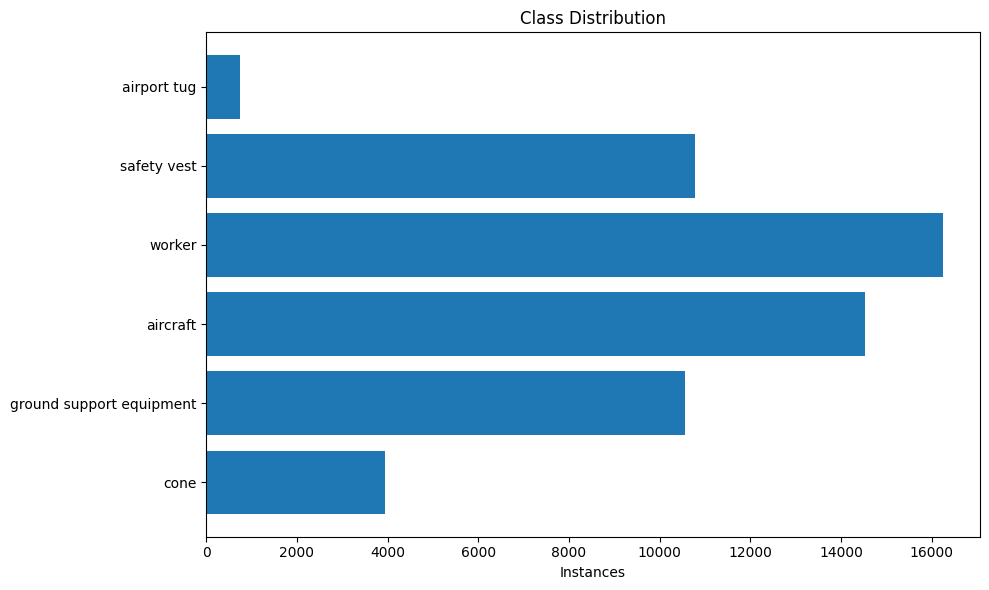

In [17]:
# =========================
# Class Distribution
# =========================
plt.figure(figsize=(10,6))

plt.barh(
    list(class_counter.keys()),
    list(class_counter.values())
)

plt.title("Class Distribution")

plt.xlabel("Instances")

plt.tight_layout()

plt.show()

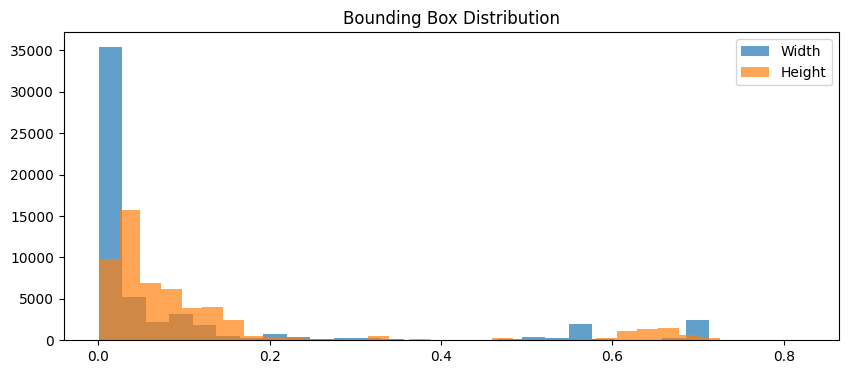

In [ ]:
# ==========================
# Bounding Box Statistics
# ==========================
plt.figure(figsize=(10,4))

plt.hist(
    bbox_width,
    bins=30,
    alpha=0.7,
    label="Width"
)

plt.hist(
    bbox_height,
    bins=30,
    alpha=0.7,
    label="Height"
)

plt.legend()

plt.title("Bounding Box Distribution")

plt.show()

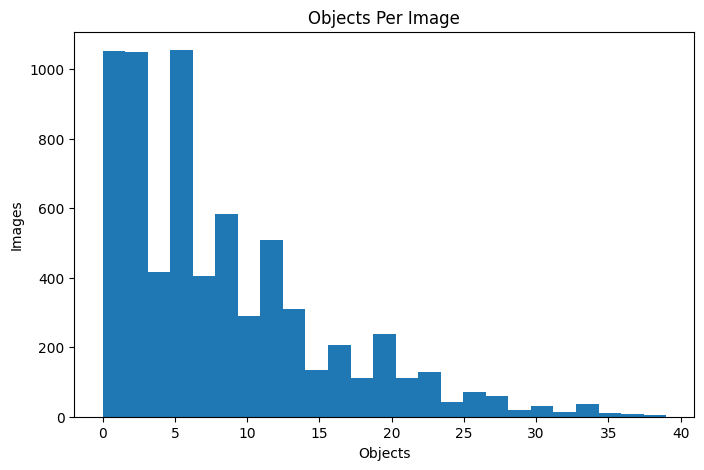

In [19]:
# =========================
# Objects Per Image
# =========================
plt.figure(figsize=(8,5))

plt.hist(
    objects_per_image,
    bins=25
)

plt.title("Objects Per Image")

plt.xlabel("Objects")

plt.ylabel("Images")

plt.show()

In [20]:
# ==================================
# Random Annotation Visualization
# ==================================
sample_images = random.sample(all_images, min(20, len(all_images)))

save_dir = OUTPUT_ROOT / "dataset_visualizations" / "random_samples"
save_dir.mkdir(exist_ok=True)

for image_path in sample_images:
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]

    label = corresponding_label(image_path)

    if label.exists():
        for line in label.read_text().splitlines():
            values = line.split()
            if len(values) != 5:
                continue

            cls = int(values[0])
            xc, yc, bw, bh = map(float, values[1:])

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

            cv2.putText(
                image,
                CLASS_NAMES[cls],
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )
    cv2.imwrite(str(save_dir / image_path.name), image)

print(f"Saved annotated samples to: {save_dir}")

Saved annotated samples to: /teamspace/studios/this_studio/Airport-AI/outputs/dataset_visualizations/random_samples


## 4. YOLO26n Training

In [ ]:
# =====================
# Configuration
# =====================
# RUNS = PROJECT_ROOT / "runs"

# WEIGHTS = RUNS / "train"

# RUN_NAME = "airport_yolo26n"

# print(DATA_YAML)

/teamspace/studios/this_studio/01-Airport-AI-Research/datasets/data.yaml


In [22]:
# =======================
# Verify Dataset
# =======================
assert DATA_YAML.exists(), "data.yaml not found."

print("Dataset located.")

print(DATA_YAML.read_text())

Dataset located.
train: datasets/airport/train/images
val: datasets/airport/valid/images
test: datasets/airport/test/images

nc: 6
names: ['aircraft', 'airport tug', 'cone', 'ground support equipment', 'safety vest', 'worker']

roboflow:
  workspace: mondal-shatakshi-samir-lipika
  project: airport-ground-operations
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mondal-shatakshi-samir-lipika/airport-ground-operations/dataset/1


In [23]:
# ==============
# Device Check
# ==============
print("CUDA:", torch.cuda.is_available())

print("GPU:", torch.cuda.get_device_name(0))

print("Torch:", torch.__version__)

CUDA: True
GPU: Tesla T4
Torch: 2.12.0+cu130


In [ ]:
# ====================
# Load YOLO26n
# ====================
# model = YOLO("yolo26n.pt")
# model.info()

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)

In [ ]:
# =======================
# Training Configuration
# =======================
training_args = dict(
    data=str(DATA_YAML),
    epochs=200, # provides sufficient learning
    imgsz=640,
    batch=16,
    workers=8,
    device=0,
    optimizer="AdamW",
    lr0=0.001,  # appropriate for fine-tuning from pretrained YOLO26n weights
    lrf=0.01,
    weight_decay=5e-4,
    warmup_epochs=3,
    patience=50,    # early stopping if convergence occurs sooner
    cache=True,
    amp=True,
    pretrained=True,
    project=str(RUNS / "train"),
    name=RUN_NAME,
    save=True,
    save_period=10,
    val=True,
    plots=True,
    verbose=True,
    seed=42,    # improves reproducibility
)

In [ ]:
# ==================
# Start Training
# ==================
# results = model.train(**training_args)

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.62 🚀 Python-3.12.11 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/teamspace/studios/this_studio/01-Airport-AI-Research/datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=

## 5. Model Evaluation

In [24]:
# ======================
# Load Best Model
# ======================
RUN_DIR = PROJECT_ROOT / "runs" / "train" / "airport_yolo26n"

BEST_MODEL = (RUN_DIR / "weights" / "best.pt")

assert BEST_MODEL.exists(), "best.pt not found"

print(BEST_MODEL)

/teamspace/studios/this_studio/Airport-AI/runs/train/airport_yolo26n/weights/best.pt


In [25]:
# ===================
# Load Model
# ===================
model = YOLO(BEST_MODEL)
model.info()

YOLO26n summary: 260 layers, 2,506,140 parameters, 0 gradients, 5.8 GFLOPs


(260, 2506140, 0, 5.782528)

In [26]:
# ====================
# Evaluate Model
# ====================
eval_results = model.val(
    data=DATA_YAML,
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    save_json=True,
    verbose=True
)

Ultralytics 8.4.62 🚀 Python-3.12.11 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,376,006 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1166.6±260.8 MB/s, size: 58.2 KB)
val: Scanning /teamspace/studios/this_studio/Airport-AI/datasets/airport/valid/labels.cache... 811 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 811/811 136.1Mit/s 0.0s
val: /teamspace/studios/this_studio/Airport-AI/datasets/airport/valid/images/03_sample_000856_jpg.rf.a7c93582290dff5623e3db6dfab36308.jpg: 1 duplicate labels removed
val: /teamspace/studios/this_studio/Airport-AI/datasets/airport/valid/images/04_sample_000008_jpg.rf.1ce383715e57d657f93b48f75dcfe68c.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 4.1it/s 12.4s0.1s
                   all        811       8135      0.815      0.722      0.758      0.577
              aircraft

In [27]:
# ===========================
# Overall Evaluation Metrics
# ===========================
metrics = {
    "Precision": eval_results.results_dict["metrics/precision(B)"],
    "Recall": eval_results.results_dict["metrics/recall(B)"],
    "mAP50": eval_results.results_dict["metrics/mAP50(B)"],
    "mAP50-95": eval_results.results_dict["metrics/mAP50-95(B)"],
    "Fitness": eval_results.results_dict["fitness"]
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Value"]
)

metrics_df["Value"] = metrics_df["Value"].round(4)

metrics_df

,Metric,Value
0,Precision,0.8147
1,Recall,0.7220
2,mAP50,0.7583
3,mAP50-95,0.5771
4,Fitness,0.5771


In [28]:
# ======================
# Save Metrics
# ======================
output = RUN_DIR / "evaluation_metrics.json"

with open(output, "w") as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

print(output)

/teamspace/studios/this_studio/Airport-AI/runs/train/airport_yolo26n/evaluation_metrics.json


In [29]:
# ======================
# Per-Class mAP
# ======================
class_names = list(eval_results.names.values())

class_ap = pd.DataFrame({
    "Class": class_names,
    "AP50-95": eval_results.maps
})

class_ap = class_ap.sort_values(
    "AP50-95",
    ascending=False
)

class_ap

,Class,AP50-95
3,ground_support_equipment,0.703853
4,safety_vest,0.640106
2,cone,0.639814
5,worker,0.605010
0,aircraft,0.568345
1,airport_tug,0.305243


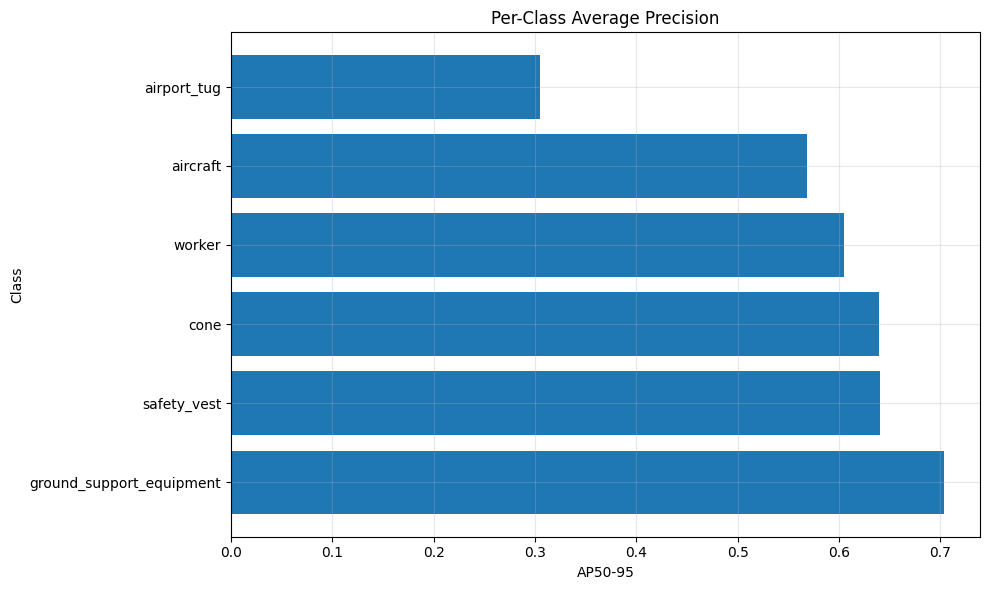

In [30]:
# ===================
# Plot Per-Class mAP
# ===================
plt.figure(figsize=(10,6))

plt.barh(
    class_ap["Class"],
    class_ap["AP50-95"]
)

plt.xlabel("AP50-95")

plt.ylabel("Class")

plt.title("Per-Class Average Precision")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [31]:
# =======================
# Identify Weak Classes
# =======================
threshold = 0.50

weak_classes = class_ap[
    class_ap["AP50-95"] < threshold
]

weak_classes

,Class,AP50-95
1,airport_tug,0.305243


In [33]:
# ======================
# Best & Worst Classes
# ======================
print("Best Classes")

display(class_ap.head(2))

print()

print("Worst Classes")

display(class_ap.tail(2))

Best Classes


,Class,AP50-95
3,ground_support_equipment,0.703853
4,safety_vest,0.640106



Worst Classes


,Class,AP50-95
0,aircraft,0.568345
1,airport_tug,0.305243


In [34]:
# ========================
# Training Results
# ========================
results_csv = RUN_DIR / "results.csv"

history = pd.read_csv(results_csv)

history.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,111.551,1.74192,2.10960,0.00798,0.48053,0.47616,0.44613,0.25618,1.42010,1.60629,0.00891,0.000332,0.000332,0.067093
1,2,198.573,1.52263,1.34316,0.00619,0.62345,0.48713,0.54631,0.32928,1.30586,1.25247,0.00689,0.000661,0.000661,0.034089
2,3,283.784,1.44588,1.15181,0.00559,0.55556,0.57099,0.58732,0.37169,1.21475,1.14125,0.00682,0.000986,0.000986,0.001080
3,4,367.692,1.40267,1.04314,0.00523,0.65376,0.54437,0.59201,0.37402,1.23362,1.05586,0.00625,0.000980,0.000980,0.000980
4,5,451.271,1.37213,0.99171,0.00508,0.70522,0.57846,0.63319,0.40947,1.17003,1.03070,0.00634,0.000974,0.000974,0.000974


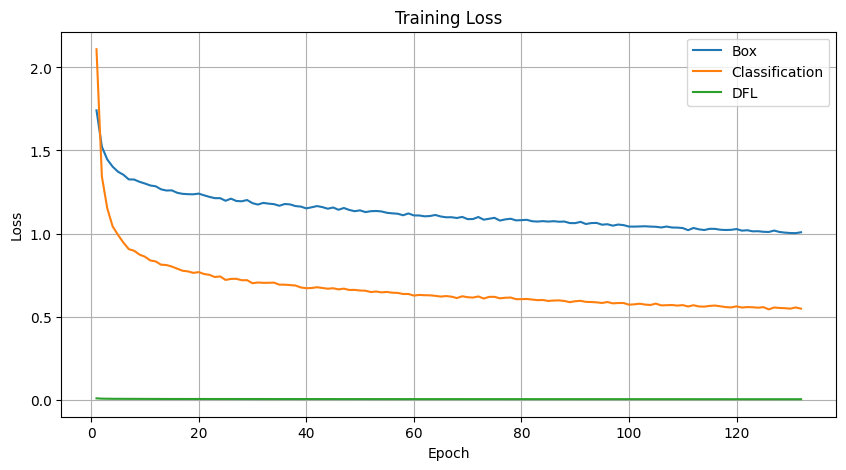

In [35]:
# ======================
# Training Loss
# ======================
plt.figure(figsize=(10,5))

plt.plot(
    history["epoch"],
    history["train/box_loss"],
    label="Box"
)

plt.plot(
    history["epoch"],
    history["train/cls_loss"],
    label="Classification"

)

plt.plot(
    history["epoch"],
    history["train/dfl_loss"],
    label="DFL"

)

plt.legend()

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

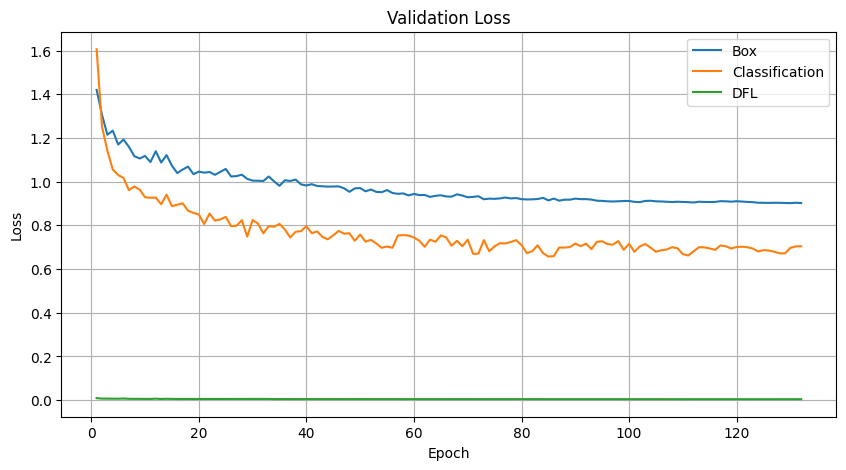

In [36]:
# ======================
# Validation Loss
# ======================
plt.figure(figsize=(10,5))

plt.plot(
    history["epoch"],
    history["val/box_loss"],
    label="Box"

)

plt.plot(
    history["epoch"],
    history["val/cls_loss"],
    label="Classification"
)

plt.plot(
    history["epoch"],
    history["val/dfl_loss"],
    label="DFL"
)

plt.legend()

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Validation Loss")

plt.show()

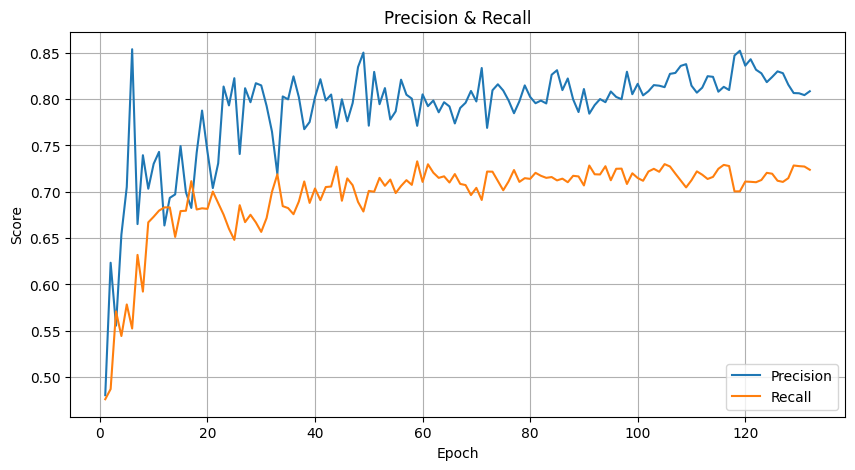

In [37]:
# =======================
# Precision & Recall
# =======================
plt.figure(figsize=(10,5))

plt.plot(
    history["epoch"],
    history["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    history["epoch"],
    history["metrics/recall(B)"],
    label="Recall"
)

plt.legend()

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Score")

plt.title("Precision & Recall")

plt.show()

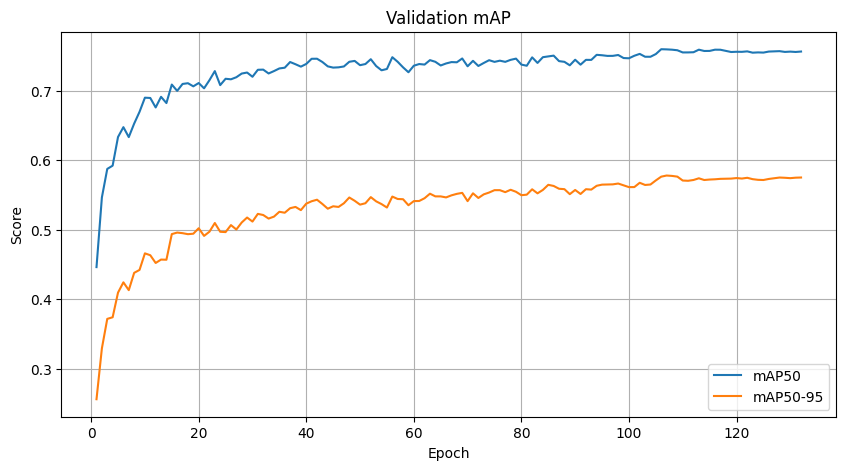

In [38]:
# ===================
# mAP Progress
# ===================
plt.figure(figsize=(10,5))

plt.plot(
    history["epoch"],
    history["metrics/mAP50(B)"],
    label="mAP50"
)

plt.plot(
    history["epoch"],
    history["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

plt.legend()

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Score")

plt.title("Validation mAP")

plt.show()

In [39]:
# ========================
# Training Summary
# ========================
print("=" * 60)

print("YOLO26n Evaluation Summary")

print("=" * 60)

print(f"Precision   : {metrics['Precision']:.4f}")

print(f"Recall      : {metrics['Recall']:.4f}")

print(f"mAP50       : {metrics['mAP50']:.4f}")

print(f"mAP50-95    : {metrics['mAP50-95']:.4f}")

print(f"Fitness     : {metrics['Fitness']:.4f}")

print()

print("Best Classes")

print(class_ap.head())

print()

print("Weak Classes")

print(weak_classes)

print("=" * 60)

YOLO26n Evaluation Summary
Precision   : 0.8147
Recall      : 0.7220
mAP50       : 0.7583
mAP50-95    : 0.5771
Fitness     : 0.5771

Best Classes
                      Class   AP50-95
3  ground_support_equipment  0.703853
4               safety_vest  0.640106
2                      cone  0.639814
5                    worker  0.605010
0                  aircraft  0.568345

Weak Classes
         Class   AP50-95
1  airport_tug  0.305243


## 6. Video Detection

In [40]:
# =====================
# Import Library
# =====================
import time
import cv2
from IPython.core.display import Video

In [41]:
# =====================
# Load Trained Model
# =====================
BEST_MODEL = (PROJECT_ROOT / "runs" / "train" / "airport_yolo26n" / "weights" / "best.pt")

assert BEST_MODEL.exists()

model = YOLO(BEST_MODEL)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
# ========================
# Configure Video
# ========================
VIDEO_DIR = PROJECT_ROOT / "data" / "videos"

INPUT_VIDEO = VIDEO_DIR / "02_sample.mp4"

OUTPUT_VIDEO = VIDEO_DIR / "02_prediction.mp4"

assert INPUT_VIDEO.exists()

print(INPUT_VIDEO)

/teamspace/studios/this_studio/01-Airport-AI-Research/videos/02_sample.mp4


In [ ]:
# ================
# Open Video
# ================
cap = cv2.VideoCapture(str(INPUT_VIDEO))

assert cap.isOpened()

In [ ]:
# =====================
# Video Properties
# =====================
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fps = cap.get(cv2.CAP_PROP_FPS)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Width :", width)
print("Height:", height)
print("FPS   :", fps)
print("Frames:", total_frames)

Width : 1920
Height: 1080
FPS   : 30.0
Frames: 2687


In [ ]:
# ====================
# Output Writer
# ====================
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(OUTPUT_VIDEO),
    fourcc,
    fps,
    (width, height)
)

In [ ]:
# =======================
# Visualization Settings
# =======================
BOX_COLOR = (0, 255, 0)

TEXT_COLOR = (255, 255, 255)

FONT = cv2.FONT_HERSHEY_SIMPLEX

LINE_WIDTH = 2

FONT_SCALE = 0.6

In [ ]:
# ======================
# Main Inference Loop
# ======================
frame_count = 0

processing_times = []

while True:
    success, frame = cap.read()

    if not success:
        break

    start = time.time()

    results = model.predict(
        source=frame,
        verbose=False,
        conf=0.25
    )

    result = results[0]

    boxes = result.boxes

    for box in boxes:
        x1,y1,x2,y2 = map(
            int,
            box.xyxy[0]
        )

        confidence = float(box.conf)

        class_id = int(box.cls)

        class_name = model.names[class_id]

        label = (
            f"{class_name} "
            f"{confidence:.2f}"
        )

        cv2.rectangle(
            frame,
            (x1,y1),
            (x2,y2),
            BOX_COLOR,
            LINE_WIDTH
        )

        cv2.putText(
            frame,
            label,
            (x1,y1-8),
            FONT,
            FONT_SCALE,
            TEXT_COLOR,
            2
        )

    elapsed = time.time() - start

    processing_times.append(elapsed)

    fps_live = 1.0 / elapsed

    cv2.putText(
        frame,
        f"FPS : {fps_live:.1f}",
        (20,40),
        FONT,
        0.9,
        (0,255,255),
        2
    )

    cv2.putText(
        frame,
        f"Objects : {len(boxes)}",
        (20,80),
        FONT,
        0.9,
        (0,255,255),
        2
    )

    writer.write(frame)

    frame_count += 1

cap.release()

writer.release()

In [ ]:
# ================
# Average FPS
# ================
average_fps = 1 / np.mean(processing_times)
print(f"Average FPS : {average_fps:.2f}")

Average FPS : 56.10


In [ ]:
# ==========
# Summary
# ==========
print("="*60)

print("Video Inference Summary")

print("="*60)

print(f"Frames Processed : {frame_count}")

print(f"Average FPS      : {average_fps:.2f}")

print(f"Output Video     : {OUTPUT_VIDEO}")

print("="*60)

Video Inference Summary
Frames Processed : 2687
Average FPS      : 56.10
Output Video     : /teamspace/studios/this_studio/01-Airport-AI-Research/videos/02_prediction.mp4


## 7. Dashboard
With Model Inference, Object Tracker, Safety Analytics

In [4]:
# ====================
# Import Libraries
# ===================
import time
from collections import defaultdict, deque

In [5]:
# =============
# Load Model
# =============
MODEL_PATH = (PROJECT_ROOT / "runs" / "train" / "airport_yolo26n" / "weights" / "best.pt")

model = YOLO(MODEL_PATH)

In [6]:
# ========
# Video
# ========
VIDEO_DIR = PROJECT_ROOT / "videos"

INPUT_VIDEO = VIDEO_DIR / "02_sample.mp4"

OUTPUT_VIDEO = VIDEO_DIR / "02_tracking.mp4"

cap = cv2.VideoCapture(str(INPUT_VIDEO))

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fps = cap.get(cv2.CAP_PROP_FPS)

writer = cv2.VideoWriter(
    str(OUTPUT_VIDEO),
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

### 7A. Spatial-Temporal Analytics

In [7]:
# =====================
# Safety Constants
# =====================
PPE_DISTANCE = 80

WORKER_TOOL_DISTANCE = 120

FOD_STATIONARY_FRAMES = 50

AIRCRAFT_ZONE_MARGIN = 80

TURNAROUND_TIMEOUT = 300

FRAME_TIME = 1 / fps

In [8]:
# ====================
# Zone Definition
# ====================
# Airport Zones
zones = {
    "AIRCRAFT": (250,120,980,640),
    "SERVICE_ROAD": (0,650,1280,720),
    "STAND": (180,90,1050,660)
}

In [9]:
# ======================
# Helper Functions
# ======================
# Center of Bounding Box
def center(box):
    x1,y1,x2,y2 = box
    return (
        int((x1+x2)/2),
        int((y1+y2)/2)
    )

# Euclidean Distance
def distance(a,b):
    return np.linalg.norm(
        np.array(a)-np.array(b)
    )

# Zone Membership
def inside_zone(point, zone):
    x,y = point
    x1,y1,x2,y2 = zone
    return (
        x1 <= x <= x2
        and
        y1 <= y <= y2
    )

In [10]:
# ============================
# PPE Analytics
# ============================
def evaluate_ppe(workers, vests):
    alerts = []

    for worker in workers:
        safe = False
        wc = worker["center"]
        for vest in vests:
            vc = vest["center"]
            if distance(wc,vc) < PPE_DISTANCE:
                safe = True
                break

        if not safe:
            alerts.append({
                "type":"PPE",
                "severity":"HIGH",
                "object":worker
            })

    return alerts

In [11]:
# ======================
# FOD Analytics
# ======================
# Tracking memory
fod_memory = defaultdict(int)

# Analytics
def evaluate_fod(tools, workers):
    alerts = []

    for tool in tools:
        isolated = True
        tc = tool["center"]
        for worker in workers:
            if distance(
                tc,
                worker["center"]
            ) < WORKER_TOOL_DISTANCE:
                isolated = False
                break

        if isolated:
            tid = tool["id"]
            fod_memory[tid] += 1
            if fod_memory[tid] > FOD_STATIONARY_FRAMES:
                alerts.append({
                    "type":"FOD",
                    "severity":"HIGH",
                    "object":tool
                })

        else:
            fod_memory[tool["id"]] = 0

    return alerts

In [12]:
# ======================
# Turnaround Analytics
# ======================
required_sequence = [
    "bridge_connected",
    "fuel_truck",
    "pushback_tractor"
]

# Aircraft memory
turnaround_state = defaultdict(list)

# Evaluation
def evaluate_turnaround(
    aircraft,
    objects
):
    alerts = []

    for plane in aircraft:
        pid = plane["id"]
        sequence = []

        for obj in objects:
            if distance(
                plane["center"],
                obj["center"]
            ) < 250:
                sequence.append(
                    obj["class"]
                )

        turnaround_state[pid] = sequence

        missing = [
            x
            for x in required_sequence
            if x not in sequence
        ]

        if len(missing):
            alerts.append({
                "type":"TURNAROUND",
                "severity":"MEDIUM",
                "missing":missing,
                "object":plane
            })

    return alerts

### 7B. Multi-Object Tracking

In [13]:
# =========================
# ByteTrack Configuration
# =========================
TRACKER = "bytetrack.yaml"

CONFIDENCE = 0.25

IOU = 0.45

In [14]:
# ====================
# Tracking Memory
# ====================
track_history = defaultdict(
    lambda: deque(maxlen=50)
)

track_age = defaultdict(int)

track_speed = {}

frame_number = 0

### 7C. Dashboard

In [15]:
# ======================
# Dashboard State
# ======================
event_log = deque(maxlen=10)

In [16]:
# =====================
# Display Function
# =====================
def render_dashboard(
    frame,
    aircraft,
    workers,
    vests,
    tools,
    alerts,
    event_log
):

    plt.figure(figsize=(14,8))
    plt.imshow(
        cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")

    plt.title("Airport AI Live Dashboard")

    plt.show()

    print("="*70)

    print("OBJECT COUNTS")

    print("="*70)

    print(f"Aircraft      : {len(aircraft)}")

    print(f"Workers       : {len(workers)}")

    print(f"Safety Vest   : {len(vests)}")

    print(f"Tools / FOD   : {len(tools)}")

    print()

    print("="*70)

    print("SAFETY STATUS")

    print("="*70)

    # ===============
    # PPE Status
    # ===============
    if any(a["type"] == "PPE" for a in alerts):
        print("⚠️ PPE Violation")
    else:
        print("✅ PPE Compliance")
    
    # ===============
    # FOD Status
    # ===============
    if any(a["type"] == "FOD" for a in alerts):
        print("⚠️ Foreign Object Debris")
    else:
        print("✅ No FOD")

    # ===================
    # Turnaround Status
    # ===================
    if any(a["type"] == "TURNAROUND" for a in alerts):
        print("⚠️ Turnaround Sequence")
    else:
        print("✅ Turnaround Complete")

    # ====================
    # Event Log
    # ====================
    print()

    print("="*70)

    print("RECENT EVENTS")

    print("="*70)

    for event in reversed(event_log):
        print(
            f"{event["time"]}   {event['event']}"
        )

### 7D. Performance Evaluation

In [17]:
# ==========================================================
# Performance Statistics
# ==========================================================

import time

fps_history = []

confidence_history = []

objects_history = []

tracks_history = []

alerts_history = []

frame_history = []

detection_history = []

frame_number = 0

start_time = time.time()

### Main Loop

In [ ]:
# ====================
# Main Tracking Loop
# ====================
while True:
    success, frame = cap.read()

    if not success:
        break

    frame_number += 1

    start = time.time()

    results = model.track(
        source=frame,
        persist=True,
        tracker=TRACKER,
        conf=CONFIDENCE,
        iou=IOU,
        verbose=False
    )

    result = results[0]

    boxes = result.boxes

    # =============================
    # Analytics Objects
    # =============================
    workers = []
    vests = []
    tools = []
    aircraft = []
    turnaround_objects = []
    objects = []

    if boxes.id is None:
        writer.write(frame)
        continue

    for box in boxes:
        x1,y1,x2,y2 = map(
            int,
            box.xyxy[0]
        )

        class_id = int(box.cls)

        class_name = model.names[class_id]

        confidence = float(box.conf)

        track_id = int(box.id)

        center = (
            int((x1+x2)/2),
            int((y1+y2)/2)
        )

        # ==============================
        # Create Analytics Object
        # ==============================
        obj = {
            "id": track_id,
            "class": class_name,
            "bbox": (x1, y1, x2, y2),
            "center": center,
            "confidence": confidence
        }

        objects.append(obj)

        # =============================
        # Categorize Objects
        # =============================
        if class_name == "person":
            workers.append(obj)

        elif class_name == "safety_vest":
            vests.append(obj)

        elif class_name in [
            "tool",
            "debris"
        ]:
            tools.append(obj)

        elif class_name == "aircraft":
            aircraft.append(obj)

        elif class_name in [
            "bridge_connected",
            "fuel_truck",
            "fueling",
            "ground_power",
            "pushback_tractor",
            "ramp_loader",
            "rolling_stairway",
            "stairway",
            "bus",
            "baggage_truck",
            "catering_truck"
        ]:
            turnaround_objects.append(obj)

        track_history[track_id].append(center)

        track_age[track_id] += 1

        cv2.rectangle(
            frame,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

        cv2.putText(
            frame,
            f"{class_name}",
            (x1,y1-45),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,255,255),
            2
        )

        cv2.putText(
            frame,
            f"ID : {track_id}",
            (x1,y1-25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,255),
            2
        )

        cv2.putText(
            frame,
            f"{confidence:.2f}",
            (x1,y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,255),
            2
        )

        # ========================
        # Trajectory & Speed
        # ========================
        history = track_history[track_id]

        if len(history) >= 2:
            dx = history[-1][0] - history[-2][0]
            dy = history[-1][1] - history[-2][1]
            pixel_speed = np.sqrt(
                dx**2 + dy**2
            )
            track_speed[track_id] = pixel_speed

        else:
            pixel_speed = 0

        for i in range(1, len(history)):
            cv2.line(
                frame,
                history[i-1],
                history[i],
                (255,0,0),
                2
            )

        cv2.putText(
            frame,
            f"Speed : {pixel_speed:.1f}",
            (x1,y2+20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,255),
            2
        )

        cv2.putText(
            frame,
            f"Age : {track_age[track_id]}",
            (x1,y2+40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,255),
            2
        )
    
    # ==========================================================
    # Safety Analytics
    # ==========================================================
    ppe_alerts = evaluate_ppe(
        workers,
        vests
    )

    fod_alerts = evaluate_fod(
        tools,
        workers
    )

    turnaround_alerts = evaluate_turnaround(
        aircraft,
        turnaround_objects
    )

    # ==========================================================
    # Merge Alerts
    # ==========================================================

    all_alerts = (
        ppe_alerts +
        fod_alerts +
        turnaround_alerts
    )

    # ==========================================================
    # Update Event Log
    # ==========================================================

    for alert in all_alerts:
        event_log.append({
            "time": time.strftime("%H:%M:%S"),
            "event": alert["type"]
        })
        if len(event_log) > 100:
            event_log.pop(0)

    # ==========================================================
    # Safety Overlay
    # ==========================================================

    y = 70

    for alert in all_alerts:
        obj = alert["object"]

        x1,y1,x2,y2 = obj["bbox"]

        colour = {
            "HIGH":(0,0,255),
            "MEDIUM":(0,165,255),
            "LOW":(0,255,0)

        }[alert["severity"]]

        cv2.rectangle(
            frame,
            (x1,y1),
            (x2,y2),
            colour,
            3
        )

        cv2.putText(
            frame,
            alert["type"],
            (x1,y1-25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            colour,
            2
        )

        y += 30
    
    # =============
    # FPS Overlay
    # =============
    # elapsed = time.time() - start

    # fps_live = 1.0 / elapsed

    # cv2.putText(
    #     frame,
    #     f"FPS : {fps_live:.1f}",
    #     (20,35),
    #     cv2.FONT_HERSHEY_SIMPLEX,
    #     0.8,
    #     (0,255,255),
    #     2
    # )

    # =====================
    # Compute Performance
    # =====================
    frame_time = time.time() - start
    fps_live = 1.0 / frame_time if frame_time > 0 else 0
    cv2.putText(
        frame,
        f"FPS : {fps_live:.1f}",
        (20,35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,255),
        2
    )
    fps_history.append(fps_live)
    objects_history.append(len(objects))
    tracks_history.append(len(set(obj["id"] for obj in objects)))
    alerts_history.append(len(all_alerts))
    confidence_history.append(
        np.mean([obj["confidence"] for obj in objects])
        if objects else 0
    )

    # ======================
    # Notebook Dashboard
    # ======================
    render_dashboard(
    frame,
    aircraft,
    workers,
    vests,
    tools,
    all_alerts,
    event_log
    )
        
    writer.write(frame)

cap.release()
writer.release()

In [ ]:
# ================
# Visualization
# ================
for alert in all_alerts:
    obj = alert["object"]

    x1,y1,x2,y2 = obj["bbox"]

    colour = {
        "HIGH":(0,0,255),
        "MEDIUM":(0,165,255),
        "LOW":(0,255,0)

    }[alert["severity"]]

    cv2.rectangle(
        frame,
        (x1,y1),
        (x2,y2),
        colour,
        3
    )

    cv2.putText(
        frame,
        alert["type"],
        (x1,y1-25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        colour,
        2
    )

# # For turnaround violations, include the missing service
# if alert["type"] == "TURNAROUND":
#     cv2.putText(
#         frame,
#         f"Missing: {','.join(alert['missing'])}",
#         (x1,y2+20),
#         cv2.FONT_HERSHEY_SIMPLEX,
#         0.55,
#         colour,
#         2
#     )

In [ ]:
# ====================
# Summary Statistics
# ====================
# print("="*60)
# print("Safety Analytics Summary")
# print("="*60)

# print(f"PPE Violations       : {len(ppe_alerts)}")
# print(f"FOD Alerts           : {len(fod_alerts)}")
# print(f"Turnaround Alerts    : {len(turnaround_alerts)}")
# print(f"Total Safety Events  : {len(all_alerts)}")

Safety Analytics Summary
PPE Violations       : 0
FOD Alerts           : 0
Turnaround Alerts    : 1
Total Safety Events  : 1


## 12. Export Results